### Time Series Output 


In [1]:
import sys
from pathlib import Path

# Add workspace root to path
workspace_root = Path.cwd().parent  # Goes up one level from Tech_Index
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

# Now import
from Data_Source.get_price import get_yahoo_data_comprehensive

# Use it
df = get_yahoo_data_comprehensive("TSLA", 1000)
print(df.head()) 

ModuleNotFoundError: No module named 'Data_Source'

### SMC Index

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def plot_smc_chart(
    df: pd.DataFrame,
    show_candles: bool = True,
    show_swings: bool = True,
    show_bos: bool = True,
    show_order_blocks: bool = True,
    show_equal_high_low: bool = True,
    show_fvg: bool = True,
    show_zones: bool = True,
):
    """
    Smart Money Concepts Visualization (Full Version)
    - Candles
    - Swing Highs/Lows
    - BOS / CHoCH
    - Order Blocks
    - Equal Highs/Lows
    - Fair Value Gaps (FVG)
    - Premium/Discount Zones
    """

    # --- Clean data
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values('date', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # --- Compute trend direction
    df['trend'] = np.where(df['close'] > df['open'], 'bull', 'bear')

    # --- Swing highs/lows detection
    df['swing_high'] = df['high'][(df['high'] > df['high'].shift(1)) &
                                  (df['high'] > df['high'].shift(-1))]
    df['swing_low']  = df['low'][(df['low']  < df['low'].shift(1)) &
                                 (df['low']  < df['low'].shift(-1))]

    # --- Structure points (BOS / CHoCH)
    structure_points = []
    last_trend = None
    last_high = None
    last_low = None

    for i in range(len(df)):
        high = df.loc[i, 'swing_high']
        low = df.loc[i, 'swing_low']
        date = df.loc[i, 'date']

        # Bullish BOS
        if pd.notna(high) and last_high is not None:
            if high > last_high:
                label = 'CHoCH ↑' if last_trend == 'bearish' else 'BOS ↑'
                structure_points.append((i, date, high, label))
                last_trend = 'bullish'
            last_high = high

        # Bearish BOS
        if pd.notna(low) and last_low is not None:
            if low < last_low:
                label = 'CHoCH ↓' if last_trend == 'bullish' else 'BOS ↓'
                structure_points.append((i, date, low, label))
                last_trend = 'bearish'
            last_low = low

        # Initialize
        if pd.notna(high) and last_high is None:
            last_high = high
        if pd.notna(low) and last_low is None:
            last_low = low

    # --- Order Blocks
    order_blocks = []
    for i, (idx, date, price, label) in enumerate(structure_points):
        if 'BOS' in label:
            prev_idx = max(idx - 1, 0)
            prev = df.loc[prev_idx]
            start_date = prev['date']
            end_date = df['date'].iloc[-1]

            if '↑' in label:
                order_blocks.append((start_date, end_date, prev['low'], prev['high'], 'bullish'))
            else:
                order_blocks.append((start_date, end_date, prev['low'], prev['high'], 'bearish'))

    # --- Equal Highs / Lows (EQH / EQL)
    eq_levels = []
    threshold = 0.1  # ~0.1% price tolerance
    if show_equal_high_low:
        for i in range(1, len(df)):
            if abs(df.loc[i, 'high'] - df.loc[i - 1, 'high']) / df.loc[i, 'high'] < threshold:
                eq_levels.append((df.loc[i, 'date'], df.loc[i, 'high'], 'EQH'))
            if abs(df.loc[i, 'low'] - df.loc[i - 1, 'low']) / df.loc[i, 'low'] < threshold:
                eq_levels.append((df.loc[i, 'date'], df.loc[i, 'low'], 'EQL'))

    # --- Fair Value Gaps (FVG)
    fvg_boxes = []
    if show_fvg:
        for i in range(2, len(df)):
            # Bullish FVG: candle (i-2).high < candle (i).low
            if df.loc[i - 2, 'high'] < df.loc[i, 'low']:
                fvg_boxes.append((df.loc[i - 2, 'date'], df.loc[i, 'date'],
                                  df.loc[i - 2, 'high'], df.loc[i, 'low'], 'bullish'))
            # Bearish FVG: candle (i-2).low > candle (i).high
            elif df.loc[i - 2, 'low'] > df.loc[i, 'high']:
                fvg_boxes.append((df.loc[i - 2, 'date'], df.loc[i, 'date'],
                                  df.loc[i, 'high'], df.loc[i - 2, 'low'], 'bearish'))

    # --- Premium / Discount Zones
    if show_zones:
        recent_high = df['high'].rolling(window=20).max()
        recent_low = df['low'].rolling(window=20).min()
        df['eq_mid'] = (recent_high + recent_low) / 2  # equilibrium

    # --- Create plot
    fig, ax = plt.subplots(figsize=(13,7))
    ax.set_title("Smart Money Concepts – Full Visualization")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    # --- 1️⃣ Candles
    if show_candles:
        width = 0.4
        for _, row in df.iterrows():
            color = '#00c176' if row['trend'] == 'bull' else '#ff4d4d'
            ax.plot([row['date'], row['date']], [row['low'], row['high']], color='black', linewidth=1)
            ax.add_patch(
                plt.Rectangle(
                    (mdates.date2num(row['date']) - width/2, min(row['open'], row['close'])),
                    width, abs(row['close'] - row['open']),
                    facecolor=color, edgecolor='black', linewidth=0.5
                )
            )

    # --- 2️⃣ Swings
    if show_swings:
        ax.scatter(df['date'], df['swing_high'], color='red', marker='^', s=80, label='Swing High')
        ax.scatter(df['date'], df['swing_low'], color='green', marker='v', s=80, label='Swing Low')

    # --- 3️⃣ BOS / CHoCH
    if show_bos:
        for (_, date, price, label) in structure_points:
            color = 'blue' if '↑' in label else 'purple'
            offset = 0.3 if '↑' in label else -0.3
            ax.text(date, price * (1 + offset/100), label, color=color, fontsize=9, ha='center', va='bottom')

    # --- 4️⃣ Order Blocks
    if show_order_blocks:
        for (start_date, end_date, low, high, ob_type) in order_blocks:
            color = '#00ff68' if ob_type == 'bullish' else '#ff0008'
            alpha = 0.15 if ob_type == 'bullish' else 0.1
            ax.axhspan(low, high, color=color, alpha=alpha, xmin=0.0, xmax=1.0)
            ax.text(start_date, high, f"{ob_type.upper()} OB", color=color, fontsize=8, va='bottom')

    # --- 5️⃣ Equal Highs / Lows
    if show_equal_high_low:
        for (date, level, tag) in eq_levels:
            color = 'orange' if tag == 'EQH' else 'brown'
            ax.axhline(level, color=color, linestyle='--', alpha=0.6)
            ax.text(date, level, tag, color=color, fontsize=8, va='bottom')

    # --- 6️⃣ Fair Value Gaps (FVG)
    if show_fvg:
        for (start_date, end_date, top, bottom, typ) in fvg_boxes:
            color = '#aaffaa' if typ == 'bullish' else '#ffaaaa'
            ax.fill_between([start_date, end_date], bottom, top, color=color, alpha=0.2)
            ax.text(start_date, top, f"{typ.upper()} FVG", fontsize=8, color=color)

    # --- 7️⃣ Premium / Discount Zones
    if show_zones:
        ax.plot(df['date'], df['eq_mid'], color='gray', linestyle='--', label='Equilibrium Zone')
        # shade premium & discount
        ax.fill_between(df['date'], df['eq_mid'], df['high'], color='red', alpha=0.05)
        ax.fill_between(df['date'], df['eq_mid'], df['low'], color='green', alpha=0.05)

    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### price -> strcuture -> what range -> break & down -> liquid (which FVG)
### FVG: inferece price smart money： 大机构比套期保值 一次性远超当前  (5 - 10 Min best) 

### 短期指标
### Use Case：Swing 震荡行情 
### BOS + CHOCH： 上涨切换到 下 -》 choch: BOS: 在延续这波上涨， CHOCH这波行情下跌 
### Zones: zone在上面的话偏多 -》多头 空头 识别指标 
### Show_order_blocks:支撑区间，价格的支撑 -》 bid 和 ask 博弈 
### show_equal_high_low： average of Low or Hight 

## Rank0
## AI判断行情 （大方向）

## 技术指标 （择时）
## Rank 1
## a. OPT RSI  + (原油基础）：RSI (日线)) -> 先做  
## b. RBF (小时)
## c. Average 
## d. WHA(liquid)（时线）

## Rank2 
## (average + std price first) 
### 先看low high average
### 再看Bollinger Band !!! -->  60% 


## Rank3
### SMC
## Rank3
### CHOCH 看看有没有突破 这个 指标 - 》 看看 BOS出现了没 （是否延续）  
### 看看 FVG 有没有价格回补 
### 看看 Zone 支撑位置 


# Fucntions: 
## Time sensitive:
OPT RSI, RBF, Average, WHA(liquid)

##




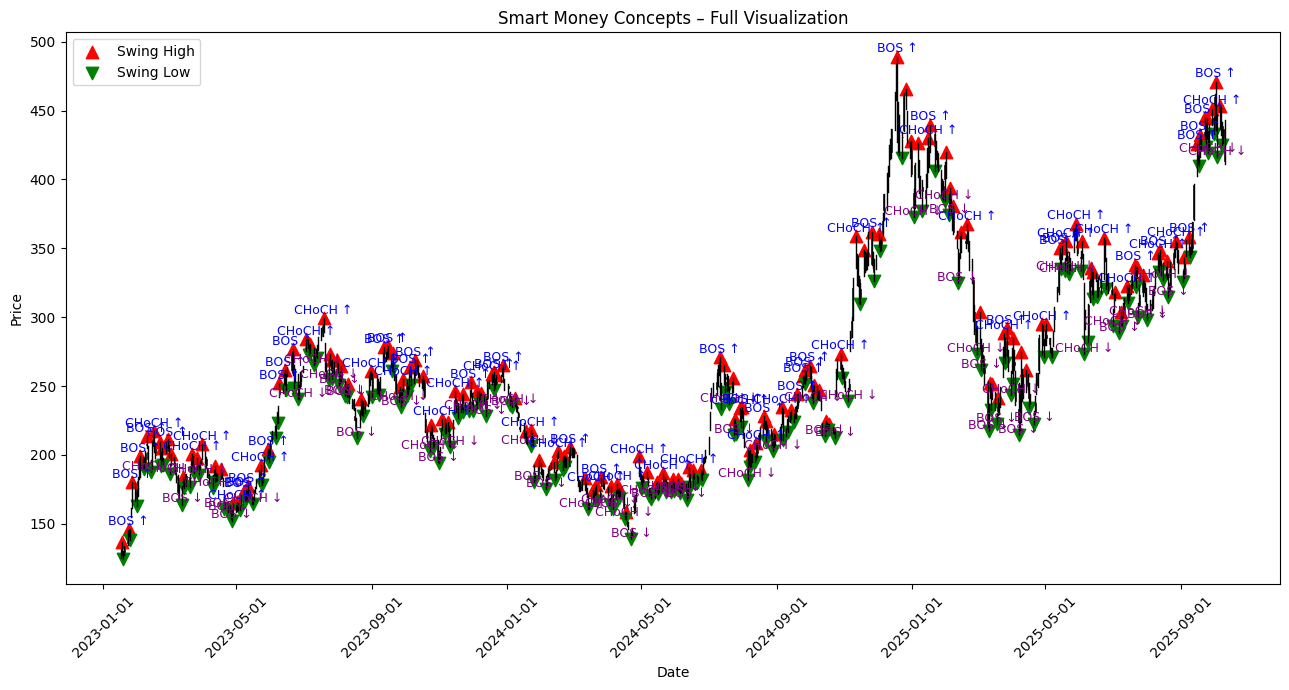

In [9]:
# Show everything
plot_smc_chart(
    df,
    show_candles=True,
    show_swings=True,
    show_bos=True,
    show_order_blocks=False,
    show_equal_high_low=False,
    show_fvg=False,
    show_zones=False
)


### Bollinger Bands Stategy

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def bollinger_strategy(df, length=20, mult=2.0):
    """
    Python version of TradingView 'Bollinger Bands Strategy'
    Input:
        df: DataFrame with ['date','open','high','low','close','volume']
        length: int, moving average period (default 20)
        mult: float, standard deviation multiplier (default 2)
    Output:
        Matplotlib visualization of price, Bollinger bands, and trades
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values('date', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # === Bollinger Bands Calculation ===
    df['basis'] = df['close'].rolling(window=length).mean()
    df['stdev'] = df['close'].rolling(window=length).std()
    df['upper'] = df['basis'] + mult * df['stdev']
    df['lower'] = df['basis'] - mult * df['stdev']

    # === Entry Signals ===
    df['buy_signal'] = (df['close'] > df['lower']) & (df['close'].shift(1) <= df['lower'].shift(1))
    df['sell_signal'] = (df['close'] < df['upper']) & (df['close'].shift(1) >= df['upper'].shift(1))

    # === Track Simple PnL ===
    df['position'] = 0
    position = 0
    for i in range(len(df)):
        if df.loc[i, 'buy_signal']:
            position = 1
        elif df.loc[i, 'sell_signal']:
            position = -1
        df.loc[i, 'position'] = position

    # Strategy return: daily % change × position
    df['return'] = df['close'].pct_change() * df['position']
    df['equity'] = (1 + df['return']).cumprod()

    # === Plot ===
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13,8), sharex=True,
                                   gridspec_kw={'height_ratios': [3,1]})

    # --- Price with Bollinger Bands ---
    ax1.plot(df['date'], df['close'], label='Close', color='black')
    ax1.plot(df['date'], df['basis'], label='Basis (SMA)', color='blue', linewidth=1.2)
    ax1.plot(df['date'], df['upper'], label='Upper Band', color='red', linestyle='--')
    ax1.plot(df['date'], df['lower'], label='Lower Band', color='green', linestyle='--')

    # Mark buy/sell points
    ax1.scatter(df.loc[df['buy_signal'], 'date'], df.loc[df['buy_signal'], 'close'],
                marker='^', color='lime', s=100, label='Buy Signal')
    ax1.scatter(df.loc[df['sell_signal'], 'date'], df.loc[df['sell_signal'], 'close'],
                marker='v', color='magenta', s=100, label='Sell Signal')

    ax1.set_title('Bollinger Bands Strategy – Python Version')
    ax1.set_ylabel('Price')
    ax1.legend()

    # --- Equity Curve ---
    ax2.plot(df['date'], df['equity'], color='red', label='Equity Curve')
    ax2.set_ylabel('Equity (relative)')
    ax2.set_xlabel('Date')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return df


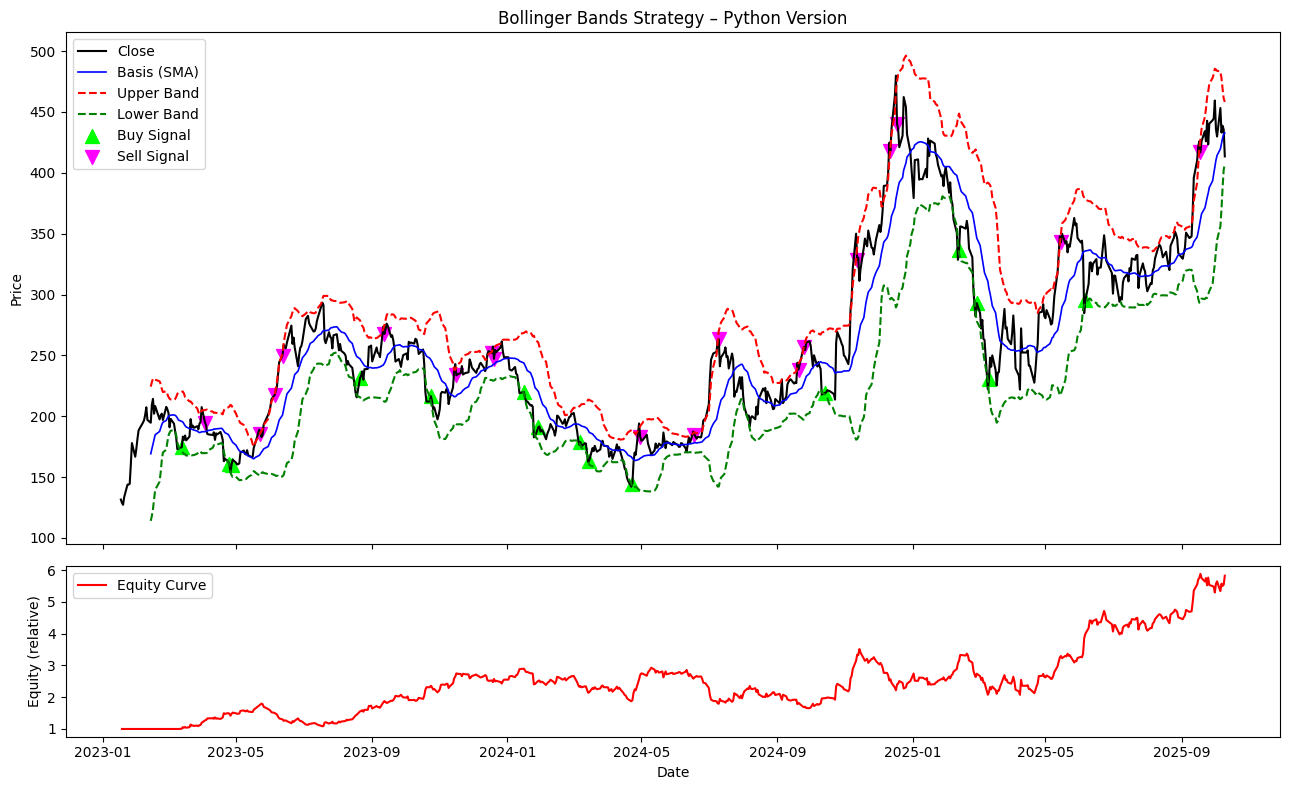

,date,open,high,low,close,volume,basis,stdev,upper,lower,buy_signal,sell_signal,position,return,equity
0,2023-01-17,125.699997,131.699997,125.019997,131.490005,186477000,NaN,NaN,NaN,NaN,False,False,0,NaN,NaN
1,2023-01-18,136.559998,136.679993,127.010002,128.779999,195680300,NaN,NaN,NaN,NaN,False,False,0,-0.000000,1.000000
2,2023-01-19,127.260002,129.990005,124.309998,127.169998,170291900,NaN,NaN,NaN,NaN,False,False,0,-0.000000,1.000000
3,2023-01-20,128.679993,133.509995,127.349998,133.419998,138858100,NaN,NaN,NaN,NaN,False,False,0,0.000000,1.000000
4,2023-01-23,135.869995,145.380005,134.270004,143.750000,203119200,NaN,NaN,NaN,NaN,False,False,0,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
682,2025-10-06,440.750000,453.549988,436.690002,453.250000,85324900,419.653000,31.851411,483.355821,355.950178,False,False,-1,-0.054487,5.340638
683,2025-10-07,447.820007,452.679993,432.450012,433.089996,102296100,423.959000,26.952821,477.864642,370.053357,False,False,-1,0.044479,5.578183
684,2025-10-08,437.570007,441.329987,425.230011,438.690002,71192100,428.503999,20.267661,469.039322,387.968677,False,False,-1,-0.012930,5.506056
685,2025-10-09,431.809998,436.350006,426.179993,435.540009,69339900,431.840500,14.632823,461.106146,402.574854,False,False,-1,0.007180,5.545591


In [11]:

bollinger_strategy(df)

### WHA (Liquity)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_liquidity_zones(
    df: pd.DataFrame,
    liq_len: int = 7,
    liq_margin: float = 2.3,
    show_buyside: bool = True,
    show_sellside: bool = True,
    show_voids: bool = True,
):
    """
    Python version of LuxAlgo's 'Buyside & Sellside Liquidity' concept.
    Input:
        df: DataFrame with ['date', 'open', 'high', 'low', 'close']
        liq_len: int, pivot lookback window
        liq_margin: float, zone height scaling factor
        show_buyside / show_sellside / show_voids: bool, toggle visibility
    Output:
        Matplotlib chart with liquidity zones
    """

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values('date', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # === Step 1: Detect swing highs and lows ===
    df['swing_high'] = (
        (df['high'] > df['high'].shift(1)) &
        (df['high'] > df['high'].shift(-1))
    ) * df['high']

    df['swing_low'] = (
        (df['low'] < df['low'].shift(1)) &
        (df['low'] < df['low'].shift(-1))
    ) * df['low']

    # === Step 2: Compute ATR for adaptive margin ===
    df['tr'] = np.maximum(df['high'] - df['low'],
                          np.maximum(abs(df['high'] - df['close'].shift(1)),
                                     abs(df['low'] - df['close'].shift(1))))
    df['atr'] = df['tr'].rolling(10).mean()

    # === Step 3: Identify Buyside & Sellside Liquidity Zones ===
    liquidity_zones = []

    for i in range(liq_len, len(df)):
        atr = df.loc[i, 'atr']
        # Buyside (above swing highs)
        if show_buyside and not np.isnan(df.loc[i, 'swing_high']):
            price = df.loc[i, 'swing_high']
            top = price + liq_margin * atr
            bottom = price
            start = df.loc[i, 'date']
            end = start + pd.Timedelta(days=10)
            liquidity_zones.append({'type': 'buyside', 'start': start, 'end': end, 'top': top, 'bottom': bottom})

        # Sellside (below swing lows)
        if show_sellside and not np.isnan(df.loc[i, 'swing_low']):
            price = df.loc[i, 'swing_low']
            top = price
            bottom = price - liq_margin * atr
            start = df.loc[i, 'date']
            end = start + pd.Timedelta(days=10)
            liquidity_zones.append({'type': 'sellside', 'start': start, 'end': end, 'top': top, 'bottom': bottom})

    # === Step 4: Liquidity Voids (large gaps between candles) ===
    voids = []
    if show_voids:
        df['gap_up'] = (df['low'] - df['high'].shift(2)) > df['atr'] * 2
        df['gap_down'] = (df['high'].shift(2) - df['low']) > df['atr'] * 2

        for i in range(2, len(df)):
            if df.loc[i, 'gap_up']:
                voids.append({'start': df.loc[i-2, 'date'], 'end': df.loc[i, 'date'],
                              'top': df.loc[i, 'low'], 'bottom': df.loc[i-2, 'high'], 'type': 'bullish'})
            elif df.loc[i, 'gap_down']:
                voids.append({'start': df.loc[i-2, 'date'], 'end': df.loc[i, 'date'],
                              'top': df.loc[i-2, 'low'], 'bottom': df.loc[i, 'high'], 'type': 'bearish'})

    # === Step 5: Visualization ===
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_title("Buyside & Sellside Liquidity Zones (Python Edition)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")

    # Candles
    width = 0.4
    for _, row in df.iterrows():
        color = '#00c176' if row['close'] >= row['open'] else '#ff4d4d'
        ax.plot([row['date'], row['date']], [row['low'], row['high']], color='black', linewidth=1)
        ax.add_patch(
            plt.Rectangle(
                (mdates.date2num(row['date']) - width/2, min(row['open'], row['close'])),
                width, abs(row['close'] - row['open']),
                facecolor=color, edgecolor='black', linewidth=0.5
            )
        )

    # Draw Liquidity Zones
    for zone in liquidity_zones:
        color = '#4caf50' if zone['type'] == 'buyside' else '#f23645'
        alpha = 0.2
        ax.fill_between(
            [zone['start'], zone['end']],
            zone['bottom'], zone['top'],
            color=color, alpha=alpha
        )
        ax.text(zone['start'], zone['top'],
                f"{zone['type'].capitalize()} Liquidity",
                color=color, fontsize=8, va='bottom')

    # Draw Liquidity Voids
    for v in voids:
        color = '#aaffaa' if v['type'] == 'bullish' else '#ffaaaa'
        ax.fill_between([v['start'], v['end']],
                        v['bottom'], v['top'],
                        color=color, alpha=0.3)
        ax.text(v['start'], v['top'], f"{v['type'].capitalize()} Void",
                color=color, fontsize=8, va='bottom')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


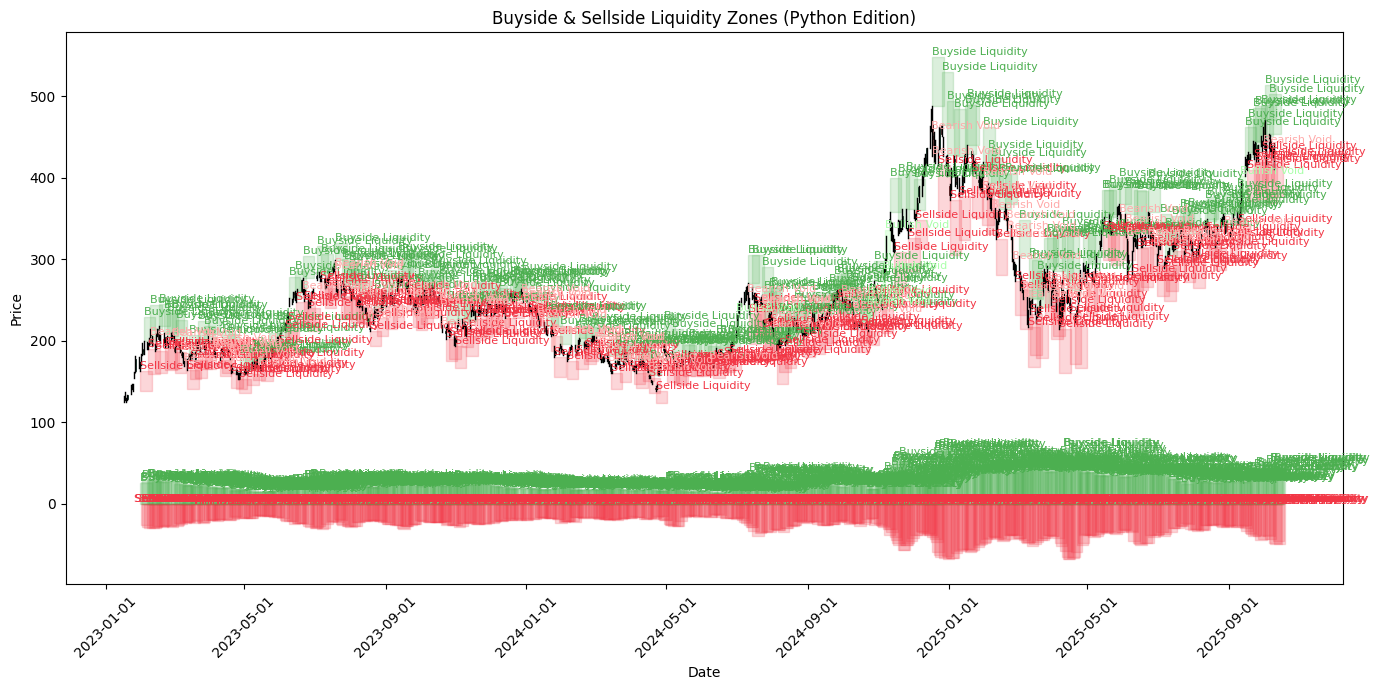

In [13]:
plot_liquidity_zones(df)

##  RSI 

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def rsi_strategy(df, length=14, overbought=70, oversold=30):
    """
    Python version of TradingView RSI Strategy
    Input:
        df: DataFrame with ['date','open','high','low','close']
        length: RSI period
        overbought: RSI upper threshold
        oversold: RSI lower threshold
    Output:
        RSI-based strategy chart + equity curve
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values('date', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # === Compute RSI ===
    delta = df['close'].diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)

    avg_gain = pd.Series(gain).rolling(length).mean()
    avg_loss = pd.Series(loss).rolling(length).mean()

    rs = avg_gain / avg_loss
    df['rsi'] = 100 - (100 / (1 + rs))

    # === Generate Signals ===
    df['buy_signal'] = (df['rsi'] > oversold) & (df['rsi'].shift(1) <= oversold)
    df['sell_signal'] = (df['rsi'] < overbought) & (df['rsi'].shift(1) >= overbought)

    # === Simulate Positions ===
    df['position'] = 0
    position = 0
    for i in range(len(df)):
        if df.loc[i, 'buy_signal']:
            position = 1
        elif df.loc[i, 'sell_signal']:
            position = -1
        df.loc[i, 'position'] = position

    # === Strategy Returns ===
    df['return'] = df['close'].pct_change() * df['position']
    df['equity'] = (1 + df['return'].fillna(0)).cumprod()

    # === Plot ===
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13,8), sharex=True,
                                   gridspec_kw={'height_ratios':[3,1]})

    # Price + Buy/Sell
    ax1.plot(df['date'], df['close'], label='Close', color='black')
    ax1.scatter(df.loc[df['buy_signal'], 'date'], df.loc[df['buy_signal'], 'close'],
                marker='^', color='lime', s=100, label='Buy Signal')
    ax1.scatter(df.loc[df['sell_signal'], 'date'], df.loc[df['sell_signal'], 'close'],
                marker='v', color='magenta', s=100, label='Sell Signal')
    ax1.set_title('RSI Strategy – Python Version')
    ax1.set_ylabel('Price')
    ax1.legend()

    # RSI indicator
    ax2.plot(df['date'], df['rsi'], label='RSI', color='blue')
    ax2.axhline(overbought, color='red', linestyle='--', linewidth=1)
    ax2.axhline(oversold, color='green', linestyle='--', linewidth=1)
    ax2.fill_between(df['date'], overbought, oversold, color='gray', alpha=0.1)
    ax2.set_title('RSI Indicator')
    ax2.set_ylabel('RSI')
    ax2.set_xlabel('Date')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # === Equity Curve ===
    plt.figure(figsize=(10,4))
    plt.plot(df['date'], df['equity'], color='red', linewidth=2, label='Strategy Equity')
    plt.title('RSI Strategy Equity Curve')
    plt.xlabel('Date')
    plt.ylabel('Equity (relative)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df






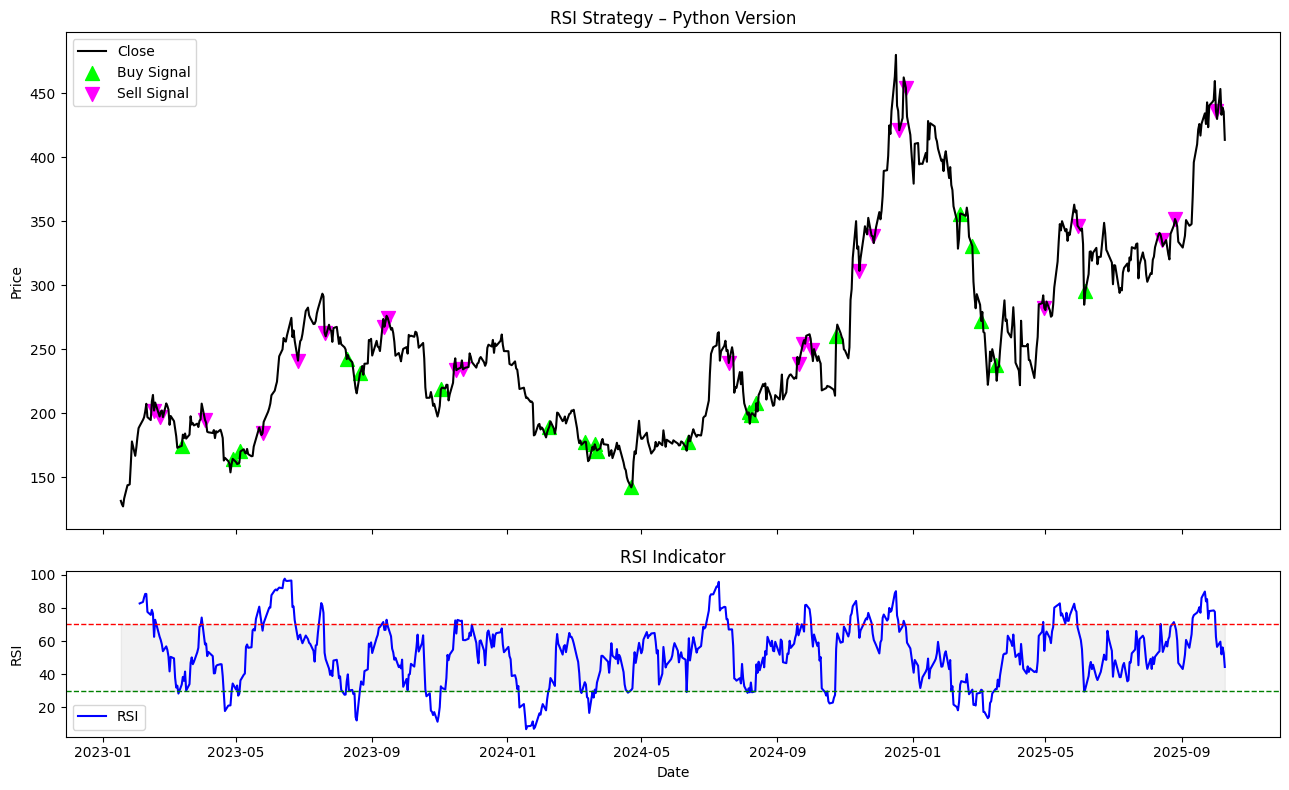

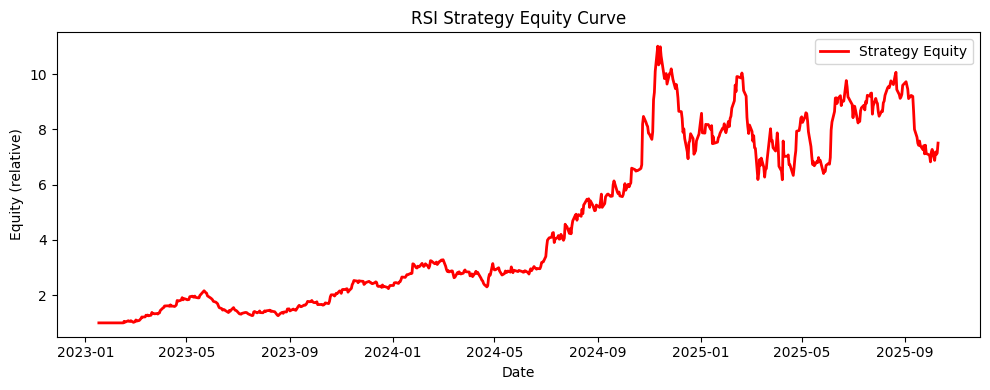

,date,open,high,low,close,volume,rsi,buy_signal,sell_signal,position,return,equity
0,2023-01-17,125.699997,131.699997,125.019997,131.490005,186477000,NaN,False,False,0,NaN,1.000000
1,2023-01-18,136.559998,136.679993,127.010002,128.779999,195680300,NaN,False,False,0,-0.000000,1.000000
2,2023-01-19,127.260002,129.990005,124.309998,127.169998,170291900,NaN,False,False,0,-0.000000,1.000000
3,2023-01-20,128.679993,133.509995,127.349998,133.419998,138858100,NaN,False,False,0,0.000000,1.000000
4,2023-01-23,135.869995,145.380005,134.270004,143.750000,203119200,NaN,False,False,0,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
682,2025-10-06,440.750000,453.549988,436.690002,453.250000,85324900,59.618080,False,False,-1,-0.054487,6.878162
683,2025-10-07,447.820007,452.679993,432.450012,433.089996,102296100,52.004439,False,False,-1,0.044479,7.184094
684,2025-10-08,437.570007,441.329987,425.230011,438.690002,71192100,56.171584,False,False,-1,-0.012930,7.091201
685,2025-10-09,431.809998,436.350006,426.179993,435.540009,69339900,52.771113,False,False,-1,0.007180,7.142119


In [15]:
rsi_strategy(df)

##  Gaussian RBF regression

## 1 hr  + 4hr


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection

# === Gaussian RBF kernel ===
def rbf_kernel(x1, x2, l):
    return np.exp(-((x1 - x2)**2) / (2 * (l**2)))


# === Machine Learning Moving Average ===
def ml_moving_average(df, window=50, sigma=10, mult=2.0, forecast=0):
    """
    Python version of LuxAlgo 'Machine Learning Moving Average'.
    Uses Gaussian Process Regression (RBF kernel) for adaptive smoothing and forecasting.
    Includes bullish/bearish color shading and trend shift markers.
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    n = len(df)
    prices = df['close'].values
    out = np.full(n, np.nan)

    # === Core GPR loop ===
    for i in range(window, n):
        X_train = np.arange(window)
        y_train = prices[i - window:i]
        mean = np.mean(y_train)
        y_train_c = y_train - mean

        # Kernel matrix
        K_train = np.zeros((window, window))
        for a in range(window):
            for b in range(window):
                K_train[a, b] = rbf_kernel(X_train[a], X_train[b], sigma)
        K_inv = np.linalg.pinv(K_train + 1e-6 * np.eye(window))

        # Test kernel vector
        x_test = np.arange(window + forecast)
        K_star = np.array([rbf_kernel(x, X_train, sigma) for x in x_test])
        K_row = K_star[-1] @ K_inv

        # Predicted value
        out[i] = np.dot(K_row, y_train_c) + mean

    # === Envelope (dynamic MAE bands) ===
    mae = pd.Series(np.abs(df['close'] - pd.Series(out))).rolling(window).mean() * mult
    upper = out + mae
    lower = out - mae

    # === Trend detection ===
    trend = np.full(n, np.nan)
    for i in range(1, n):
        if df['close'][i] > upper[i] and out[i] > out[i - 1]:
            trend[i] = 1   # Bullish
        elif df['close'][i] < lower[i] and out[i] < out[i - 1]:
            trend[i] = 0   # Bearish
        else:
            trend[i] = trend[i - 1] if i > 0 else 0

    # === Prepare colored segments ===
    x = mdates.date2num(df['date'])  # ✅ Fixed date conversion
    y = out
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    colors = ['#3179f5' if t == 1 else '#e91e63' for t in trend[1:]]

    # === Plot ===
    fig, ax = plt.subplots(figsize=(14,6))
    ax.plot(df['date'], df['close'], color='gray', alpha=0.4, label='Close')

    # Colored ML line
    lc = LineCollection(segments, colors=colors, linewidth=2.2)
    ax.add_collection(lc)

    # Bands
    ax.fill_between(df['date'], lower, upper, color='blue', alpha=0.07)

    # Circle markers for trend shifts
    shift_points = np.where(np.diff(trend) != 0)[0] + 1
    if len(shift_points) > 0:
        ax.scatter(df.loc[shift_points, 'date'], out[shift_points],
                   color=[colors[i] for i in shift_points],
                   edgecolor='black', s=60, zorder=5, label='Trend Shift')

    # --- Date axis formatting ---
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45)

    ax.set_title("Machine Learning Moving Average (LuxAlgo Style)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # === Save outputs ===
    df['ML_MA'] = out
    df['upper'] = upper
    df['lower'] = lower
    df['trend'] = trend
    return df

IndexError: list index out of range

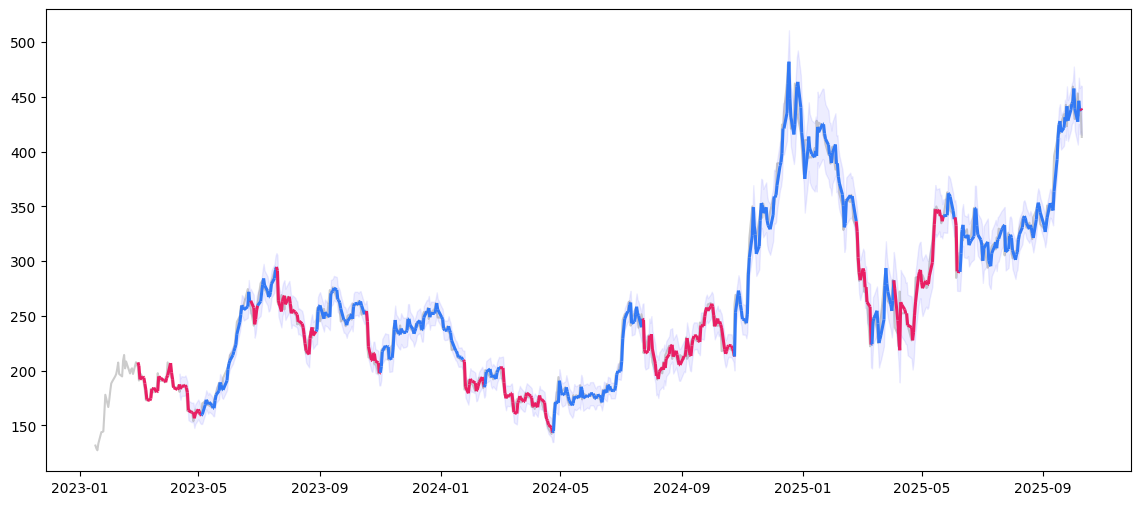

In [17]:
ml_moving_average(df, window=30, sigma=10, mult=2)

## Optimize RSI

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step1 Utility Function
def pine_sma(series, length):
    return pd.Series(series).rolling(length).mean()

def pine_rma(series, length):
    # FIX 1: Add length validation
    if length > len(series):
        return np.array([np.nan] * len(series))
    
    alpha = 1 / length
    rma = [np.nan] * len(series)
    rma[length - 1] = np.mean(series[:length])
    for i in range(length, len(series)):
        rma[i] = alpha * series[i] + (1 - alpha) * rma[i - 1]
    return np.array(rma)

def pine_rsi(close, length):
    delta = np.diff(close, prepend=close[0])
    up = np.where(delta > 0, delta, 0)
    down = np.where(delta < 0, -delta, 0)
    rs = pine_rma(up, length) / pine_rma(down, length)
    return 100 - 100 / (1 + rs)

def rational_quadratic(src, lookback=8, relative_weight=8.0, start=25, eps=1e-9):
    """
    Rational Quadratic kernel smoothing used to preprocess the price series.
    Adds epsilon to avoid division by zero.
    """
    w_sum, y_sum = 0.0, 0.0
    n = len(src)
    if n == 0:
        return np.nan

    for i in range(min(start, n)):  # limit loop to data length
        w = (1 + (i**2 / (2 * (lookback**2) * relative_weight))) ** (-relative_weight)
        y_sum += src[i] * w
        w_sum += w

    return y_sum / (w_sum + eps)



## Step2 Optimize RSI

def get_optimal_rsi_length(close, 
                           optimal_length=200, 
                           rsi_count=30, 
                           rsi_min=4, 
                           ma_length=14, 
                           backup_length=14, 
                           use_rational_quadratic=True, 
                           optimal_type="All Crossings"):
    """Scan through RSI lengths and find which one yields best crossover profit"""
    src = np.array(close)
    if use_rational_quadratic:
        src = np.array([rational_quadratic(src[:i+1]) for i in range(len(src))])
    
    cross_profits = np.zeros(rsi_count)
    
    # FIX 2: Add data length check
    max_testable_length = min(rsi_min + rsi_count, len(close) - ma_length - 1)
    if max_testable_length < rsi_min:
        return backup_length, 0.0
    
    actual_count = min(rsi_count, max_testable_length - rsi_min + 1)
    
    for i in range(actual_count):
        L = rsi_min + i
        
        # FIX 2b: Skip if RSI length is too long
        if L >= len(close):
            break
            
        rsi = pine_rsi(src, L)
        rsi_ma = pine_sma(rsi, ma_length)
        cross_type = 0
        cross_close = 0
        total_profit, cross_count = 0, 0
        
        for a in range(1, min(optimal_length, len(close))):
            # Skip if NaN values present
            if np.isnan(rsi[a]) or np.isnan(rsi_ma[a]):
                continue
                
            co = (rsi[a-1] < rsi_ma[a-1]) and (rsi[a] > rsi_ma[a])
            cu = (rsi[a-1] > rsi_ma[a-1]) and (rsi[a] < rsi_ma[a])
            if co:
                if cross_type != 0:
                    total_profit += cross_close / close[a]
                    cross_count += 1
                cross_close = close[a]
                cross_type = 1
            elif cu:
                if cross_type != 0:
                    total_profit += close[a] / cross_close
                    cross_count += 1
                cross_close = close[a]
                cross_type = -1
        cross_profits[i] = total_profit / max(cross_count, 1)

    best_idx = np.argmax(cross_profits[:actual_count])
    best_percent = cross_profits[best_idx]
    best_length = rsi_min + best_idx if best_percent > -100000 else backup_length

    return best_length, best_percent

## Step3 Machine Learning RSI


def knn_average(rsi_fast, rsi_slow, k=3, dist_type="Both", exp=False):
    distances = np.abs(rsi_slow - rsi_fast)
    idx_sorted = np.argsort(distances)
    idx_knn = idx_sorted[:k]
    vals = (rsi_fast[idx_knn] + rsi_slow[idx_knn]) / 2
    if exp:
        weights = np.exp(-distances[idx_knn])
        return np.sum(vals * weights) / np.sum(weights)
    else:
        return np.mean(vals)

def apply_ml_to_rsi(opt_rsi, ma_length=14, ml_mode="Simple Average", ml_length=10, k=3,
                    fast_length=1, slow_length=5, same_regime=False):
    """Applies simple average or KNN logic"""
    if ml_mode == "None":
        return opt_rsi[-1] if len(opt_rsi) > 0 else np.nan

    opt_rsi = np.array(opt_rsi)
    
    # FIX 3: Handle insufficient data
    if len(opt_rsi) < ma_length:
        return opt_rsi[-1] if len(opt_rsi) > 0 else np.nan
    
    rsi_ma = pine_sma(opt_rsi, ma_length)
    
    # FIX 3b: Handle NaN in rsi_ma
    if pd.isna(rsi_ma.iloc[-1]):
        return opt_rsi[-1]
    
    rsi_bull = opt_rsi[-1] >= rsi_ma.iloc[-1]

    if ml_mode == "Simple Average":
        rsi_data = []
        
        for i in range(min(ml_length, len(opt_rsi))):
            # FIX 4: Better handling of edge cases
            if i == 0:
                if len(opt_rsi) >= ma_length:
                    sma_temp = np.mean(opt_rsi[-ma_length:])
                else:
                    sma_temp = np.mean(opt_rsi)
            else:
                start_idx = max(0, len(opt_rsi) - i - ma_length)
                end_idx = len(opt_rsi) - i
                if end_idx > start_idx:
                    sma_temp = np.mean(opt_rsi[start_idx:end_idx])
                else:
                    continue
            
            temp_bull = opt_rsi[len(opt_rsi) - 1 - i] > sma_temp
            if not same_regime or temp_bull == rsi_bull:
                rsi_data.append(opt_rsi[len(opt_rsi) - 1 - i])
                
        return np.mean(rsi_data) if len(rsi_data) > 0 else opt_rsi[-1]

    else:  # KNN or KNN Exponential
        # FIX 5: Add length check for KNN
        if len(opt_rsi) < max(fast_length, slow_length):
            return opt_rsi[-1]
            
        rsi_fast = pine_sma(opt_rsi, fast_length).values
        rsi_slow = pine_sma(opt_rsi, slow_length).values
        
        # Use only valid (non-NaN) recent values
        valid_length = min(ml_length, len(opt_rsi))
        recent_fast = rsi_fast[-valid_length:]
        recent_slow = rsi_slow[-valid_length:]
        
        # Remove NaN values
        mask = ~(np.isnan(recent_fast) | np.isnan(recent_slow))
        recent_fast = recent_fast[mask]
        recent_slow = recent_slow[mask]
        
        if len(recent_fast) == 0:
            return opt_rsi[-1]
            
        return knn_average(recent_fast, recent_slow, k, exp=("Exponential" in ml_mode))



## Main Function
def optimal_rsi_strategy(df,
                         optimal_length=200,
                         rsi_count=30,
                         rsi_min=4,
                         ma_length=14,
                         backup_length=14,
                         ml_mode="Simple Average",
                         use_rational_quadratic=True):
    """
    Main wrapper for Machine Learning: Optimal RSI strategy.
    Input df: DataFrame with ['date','close']
    Output: adds ['RSI','RSI_MA','Signal','OptimalLength']
    """

    df = df.copy()
    close = df['close'].values

    # --- Step 1: find best RSI length
    rsi_length, best_percent = get_optimal_rsi_length(
        close, optimal_length, rsi_count, rsi_min, ma_length, backup_length, use_rational_quadratic
    )
    df['OptimalLength'] = rsi_length

    # --- Step 2: compute RSI and RSI_MA
    rsi = pine_rsi(close, rsi_length)
    df['RSI'] = rsi
    df['RSI_MA'] = pine_sma(rsi, ma_length)

    # --- Step 3: ML smoothing (with progress for long datasets)
    smoothed_values = []
    for i in range(len(rsi)):
        smoothed_values.append(apply_ml_to_rsi(rsi[:i+1], ma_length, ml_mode))
    df['RSI_Smoothed'] = smoothed_values

    # --- Step 4: Signals
    df['BullCross'] = (df['RSI_Smoothed'] > df['RSI_MA']) & (df['RSI_Smoothed'].shift(1) <= df['RSI_MA'].shift(1))
    df['BearCross'] = (df['RSI_Smoothed'] < df['RSI_MA']) & (df['RSI_Smoothed'].shift(1) >= df['RSI_MA'].shift(1))
    df['Signal'] = np.where(df['BullCross'], 1, np.where(df['BearCross'], -1, 0))

    # --- Step 5: Plot
    plt.figure(figsize=(14,6))
    plt.plot(df['date'], df['RSI_Smoothed'], label='RSI (ML Smoothed)', color='purple')
    plt.plot(df['date'], df['RSI_MA'], label='RSI MA', color='yellow')
    plt.axhline(70, color='gray', linestyle='--')
    plt.axhline(30, color='gray', linestyle='--')
    plt.scatter(df.loc[df['BullCross'],'date'], df.loc[df['BullCross'],'RSI_Smoothed'], color='green', s=60, label='Bull')
    plt.scatter(df.loc[df['BearCross'],'date'], df.loc[df['BearCross'],'RSI_Smoothed'], color='red', s=60, label='Bear')
    plt.title(f"Machine Learning Optimal RSI (Length={rsi_length}, Perf={best_percent:.4f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df

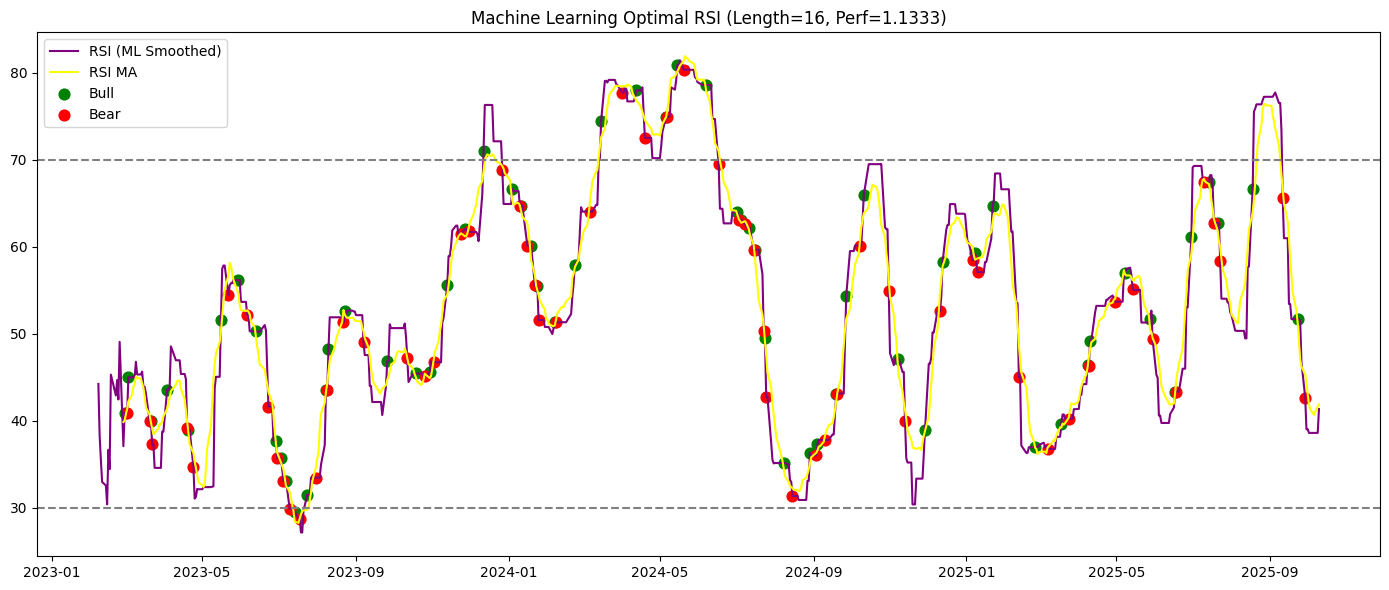

In [138]:
out = optimal_rsi_strategy(df, ml_mode="KNN Average")